Accuracy: 0.882
Precision: 0.8823203838074934
F1 Score: 0.8813375577287516

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.92      0.90      1151
           1       0.89      0.83      0.86       849

    accuracy                           0.88      2000
   macro avg       0.88      0.87      0.88      2000
weighted avg       0.88      0.88      0.88      2000



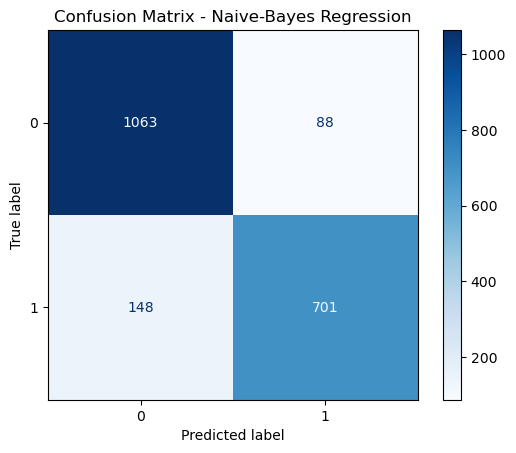

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
# Added accuracy_score and precision_score imports
from sklearn.metrics import f1_score, classification_report, accuracy_score, precision_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

df = pd.read_csv("naive_bayes_10000_dataset.csv")

df = pd.get_dummies(df, drop_first=True)

X = df.drop("placed", axis=1)
y = df["placed"]

y = LabelEncoder().fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = GaussianNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Naive-Bayes Regression")
plt.show()